<a href="https://colab.research.google.com/github/itharavenikarthik/Machine-learning/blob/main/2403A52200_ML_Lab_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("/content/drug200.csv")
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [ ]:
x=df.drop("Drug",axis=1)
y=df["Drug"]


In [ ]:
import numpy as np
x=np.array(x)
y=np.array(y).reshape(-1,1)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

param_grid = {'n_neighbors': range(1, 31)}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print("Starting GridSearchCV for KNN hyperparameter tuning...")
grid_search.fit(x_train_scaled, y_train)
print("GridSearchCV completed.")

best_n_neighbors = grid_search.best_params_['n_neighbors']
best_accuracy = grid_search.best_score_

print(f"Best n_neighbors: {best_n_neighbors}")
print(f"Best cross-validation accuracy: {best_accuracy:.4f}")

best_knn_model = KNeighborsClassifier(n_neighbors=best_n_neighbors)
best_knn_model.fit(x_train_scaled, y_train)

y_pred_best = best_knn_model.predict(x_test_scaled)

print(f"\nClassification Report for the best KNN model (n_neighbors={best_n_neighbors}):")
print(classification_report(y_test, y_pred_best))
print(f"Test Set Accuracy with Best n_neighbors: {accuracy_score(y_test, y_pred_best):.4f}")

Starting GridSearchCV for KNN hyperparameter tuning...
GridSearchCV completed.
Best n_neighbors: 16
Best cross-validation accuracy: 0.8625

Classification Report for the best KNN model (n_neighbors=16):
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        15
           1       1.00      0.83      0.91         6
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00         5
           4       1.00      0.82      0.90        11

    accuracy                           0.90        40
   macro avg       0.96      0.86      0.90        40
weighted avg       0.92      0.90      0.90        40

Test Set Accuracy with Best n_neighbors: 0.9000


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred, labels=[1,0])
print("TP  FP")
print("FN  TN")
print(cm)

TP  FP
FN  TN
[[ 6  0]
 [ 0 15]]


<function matplotlib.pyplot.show(close=None, block=None)>

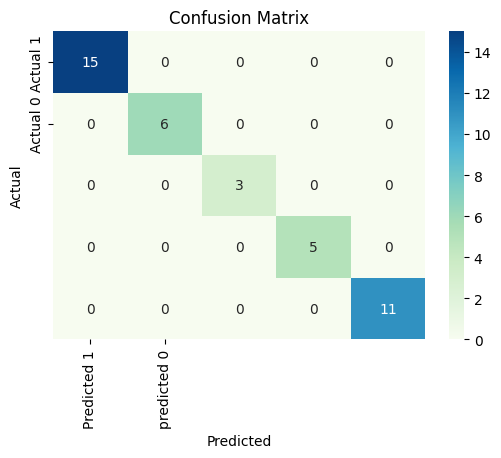

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cn=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cn,annot=True,fmt='d',cmap='GnBu',xticklabels=["Predicted 1", "predicted 0"],yticklabels=["Actual 1","Actual 0"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show

In [ ]:
dfr = pd.read_csv("/content/boston.csv")
dfr.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [ ]:
import numpy as np

xr = dfr.drop('MEDV', axis=1)
yr = dfr['MEDV']

xr = np.array(xr)
yr = np.array(yr).reshape(-1,1)

In [ ]:
from sklearn.model_selection import train_test_split
xr_train, xr_test, yr_train, yr_test = train_test_split(
    xr,yr, test_size = 0.3, random_state = 42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Xr_train = sc.fit_transform(xr_train)
Xr_test = sc.transform(xr_test)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor


knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(Xr_train, yr_train)

KNeighborsRegressor()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


yr_pred = knn_model.predict(Xr_test)


mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Absolute Error (MAE): 2.6286
Mean Squared Error (MSE): 18.8350
R-squared (R2): 0.7472


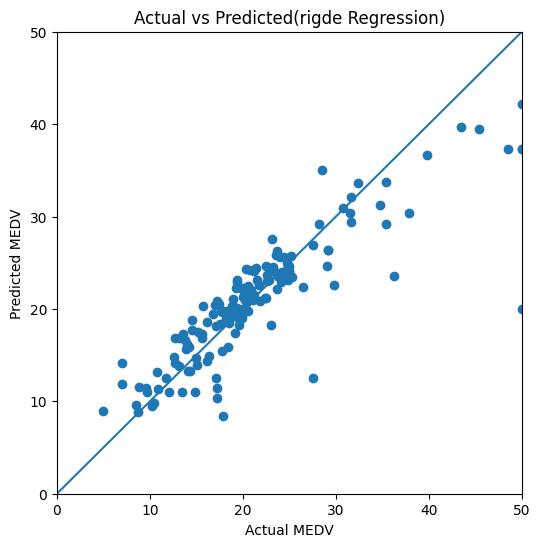

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(yr_test,yr_pred)
max_val=max(yr_test.max(),yr_pred.max())
plt.plot([0,max_val],[0,max_val],)
plt.xlim(0,max_val)
plt.ylim(0,max_val)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted(rigde Regression)")
plt.show()

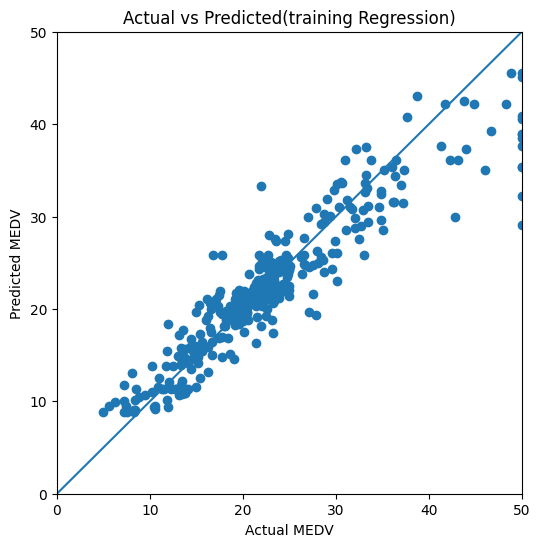

In [ ]:
plt.figure(figsize=(6,6))
yr_train_pred = knn_model.predict(Xr_train)
plt.scatter(yr_train, yr_train_pred)
plt.plot([0,max_val],[0,max_val],)
plt.xlim(0,max_val)
plt.ylim(0,max_val)
plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted(training Regression)")
plt.show()